In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import h5py

In [2]:
from rc import ESN, ESNConfig

In [3]:
with h5py.File('../../data_eigenworm/crawl.mat', 'r') as f:
    tr_refs = f['tr'][1]
    print(f"tr shape: {tr_refs.shape}")
    
    tr_data = []
    for ref in tr_refs.flatten():
        data = f[ref][:]
        tr_data.append(data)
        print(f"Data shape: {data.shape}")


tr shape: (1,)
Data shape: (5, 33600)


In [4]:
def filter_nans(pcs):
    nan_mask = np.isnan(pcs).any(axis=0)
    
    valid_indices = np.where(~nan_mask)[0]
    
    indexes_to_skip = []
    for i in range(1, len(valid_indices)):
        if valid_indices[i] - valid_indices[i-1] > 1:
            indexes_to_skip.append(i)
    
    filtered_pcs = pcs[:, ~nan_mask]
    
    return filtered_pcs, indexes_to_skip
all_pcs = []
all_skip_indices = [] 
current_index = 0

for i in range(len(tr_data)):  
    filtered_pcs, gap_indices = filter_nans(tr_data[i][:5, :])
    
    for idx in gap_indices:
        all_skip_indices.append(idx + current_index)
    
    all_pcs.append(filtered_pcs)
    current_index += filtered_pcs.shape[1]
    
    if i < len(tr_data) - 1:
        all_skip_indices.append(current_index)

all_pcs = np.hstack(all_pcs)

In [5]:
# worm_N2_scaled = StandardScaler().fit_transform(all_pcs.T).T

In [6]:
scaler = StandardScaler()
worm_N2_scaled = scaler.fit_transform(all_pcs.T).T

# Inverse transform: back to original scale
# worm_N2_original = scaler.inverse_transform(worm_N2_scaled.T).T

In [7]:
dt = 1/16

In [8]:
config = ESNConfig(
    N=10000,
    input_dim=5,
    spectral_radius=0.1809616855907689,
    alpha=1.5,
    sparsity=0.99,
    input_scaling=1.2665236214415563,
    bias_scaling=0.01,
    seed=None,
    mode='leaky',
    leaky_rate=0.7057809844406092,
)

In [9]:
config

ESNConfig(N=10000, input_dim=5, spectral_radius=0.1809616855907689, alpha=1.5, sparsity=0.99, input_scaling=1.2665236214415563, bias_scaling=0.01, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7057809844406092, beta=0.5, scale=0.1)

In [10]:
# worm_N2_scaled_resampled = worm_N2_scaled[:, ::2]

In [11]:
inputdim = 5

In [12]:
esn = ESN(config)
esn.train(worm_N2_scaled[:inputdim, :], washout=2000)

In [13]:
# esn_resampled = ESN.load("/Users/iliasoroka/RC/esn_resampled.pkl.npz")

In [14]:
# esn_resampled.train(worm_N2_scaled_resampled[:inputdim, :], washout=2000)


In [15]:
# warmup_data_resampled = worm_N2_scaled_resampled[:inputdim, :2000]
# predictions, states = esn_resampled.predict(warmup_data_resampled, steps=5000)

In [16]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn.predict(warmup_data, steps=10000)

In [17]:
read_data_slice = worm_N2_scaled[:inputdim, 4000:14000]

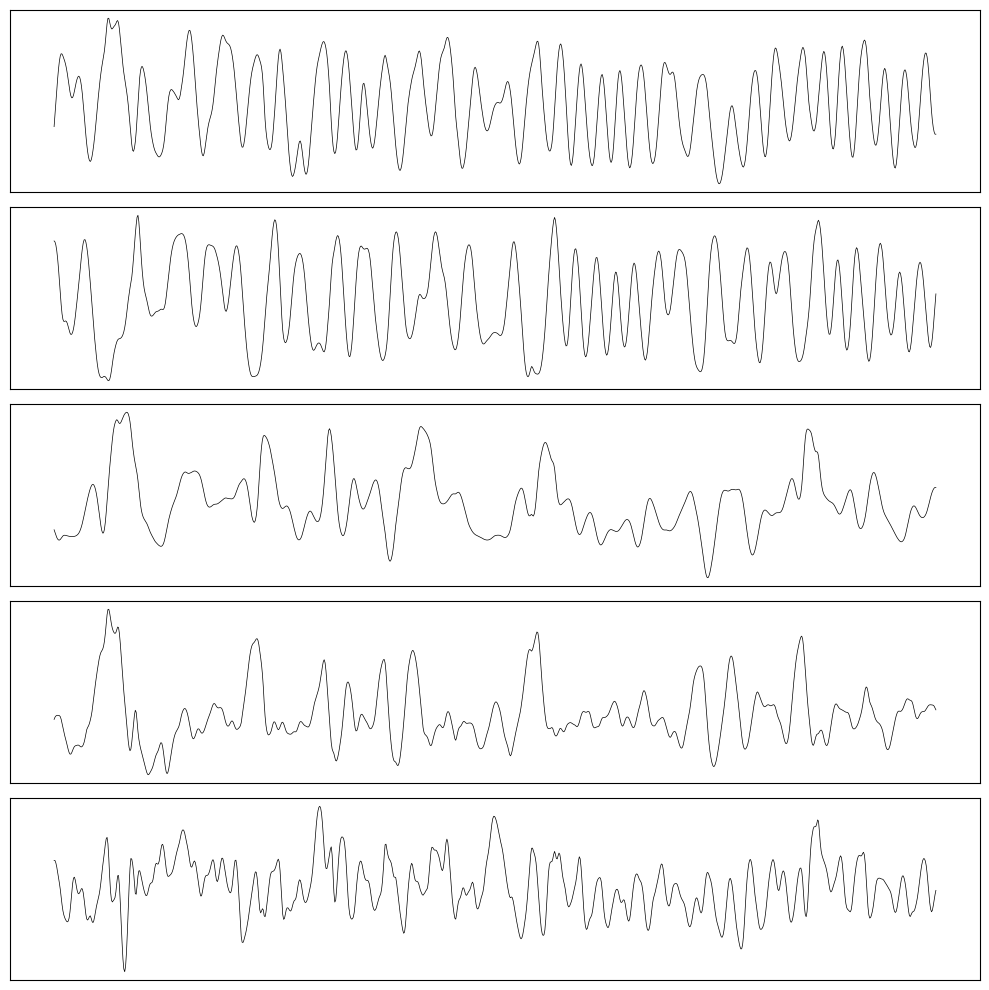

In [18]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i in range(5):
    axes[i].plot(read_data_slice[i, :1000], linewidth=0.5, color='black')
    # axes[i].set_ylabel(f'Dim {i}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('read_data_slice.svg', format='svg', transparent=True)
plt.savefig('read_data_slice.pdf', format='pdf', bbox_inches='tight')
plt.show()


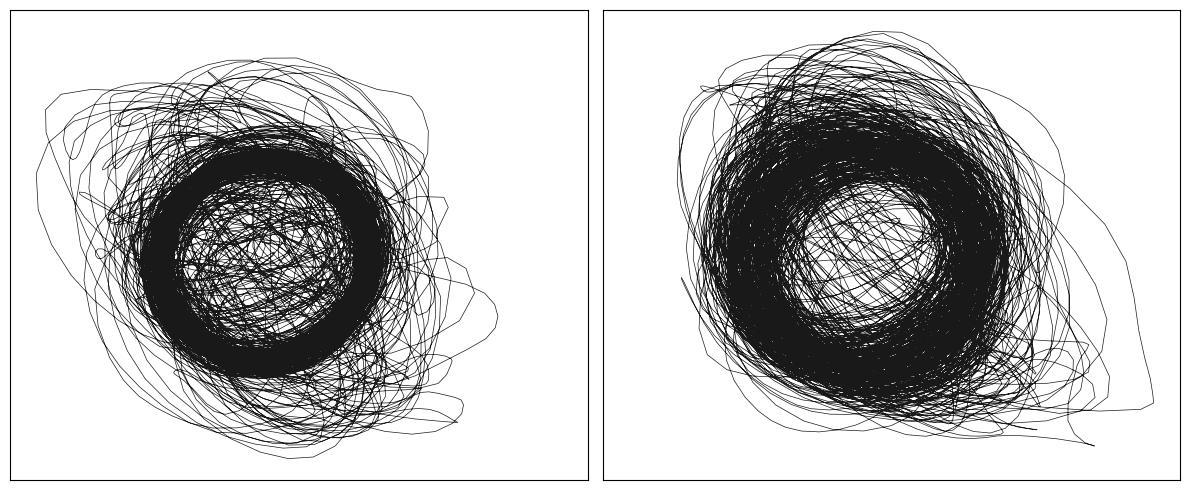

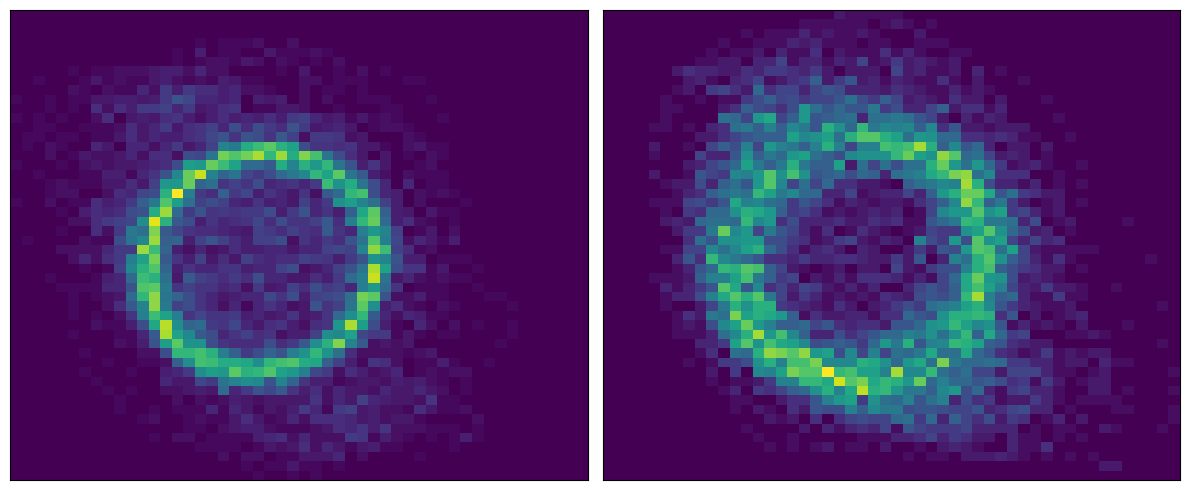

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()

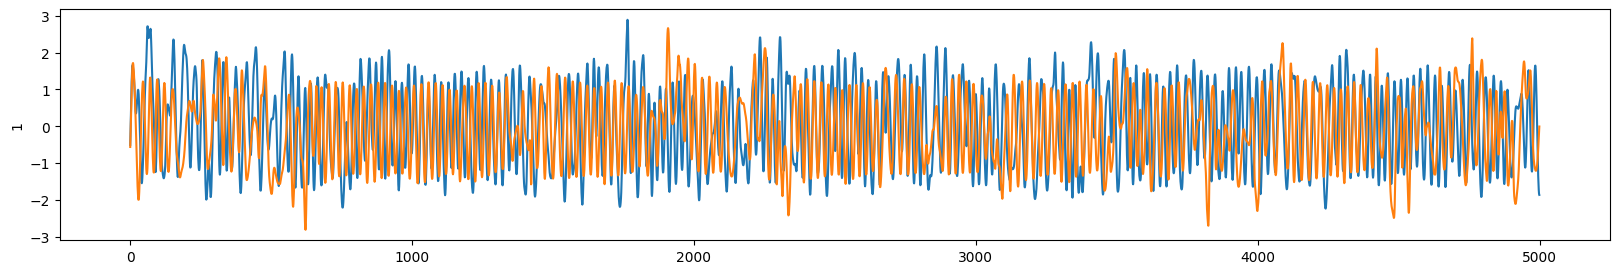

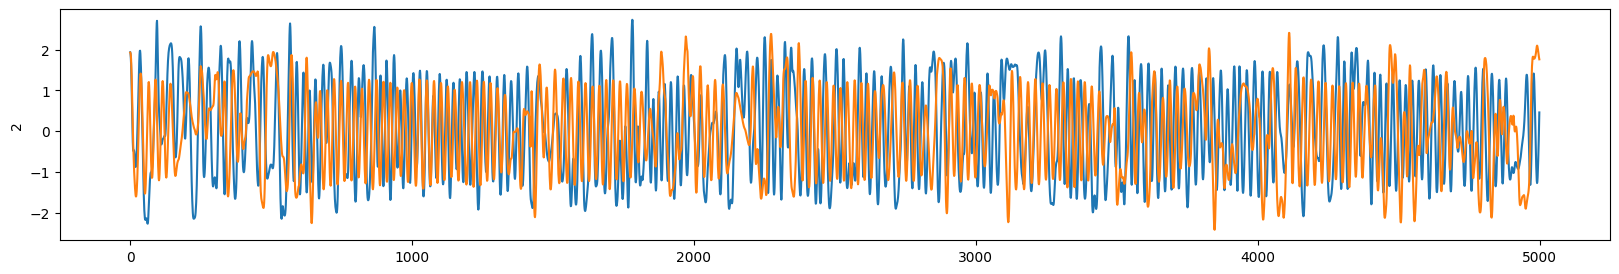

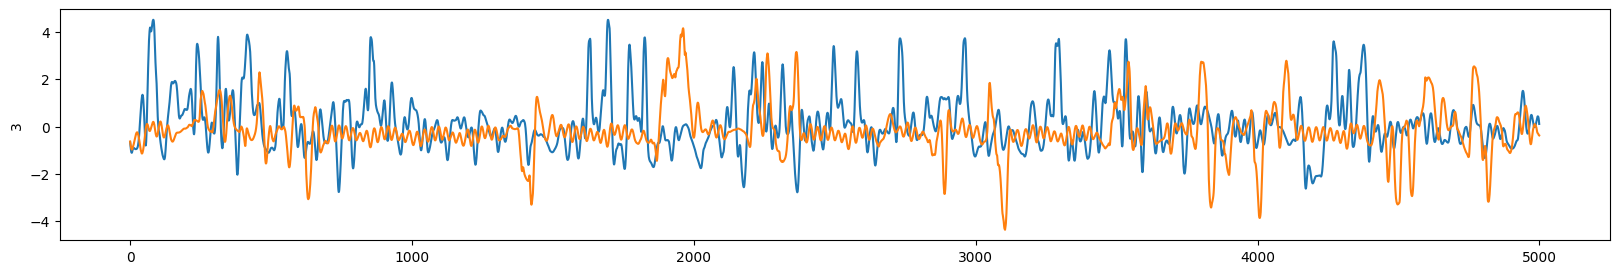

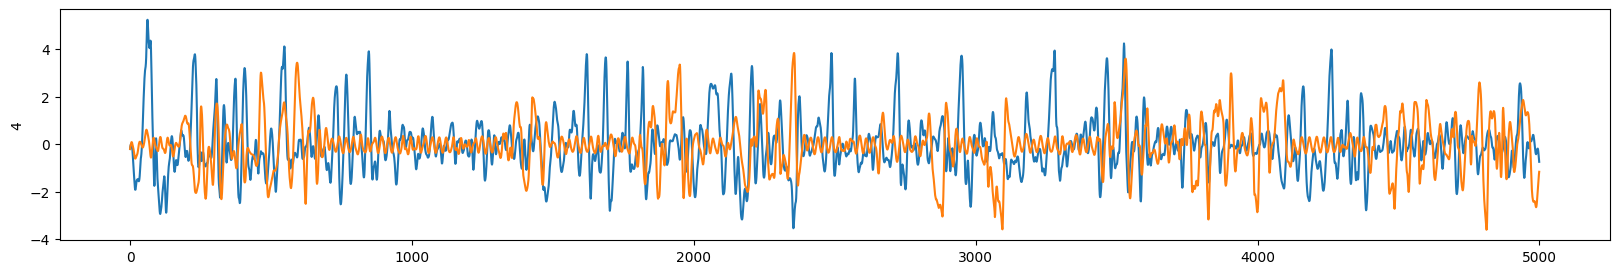

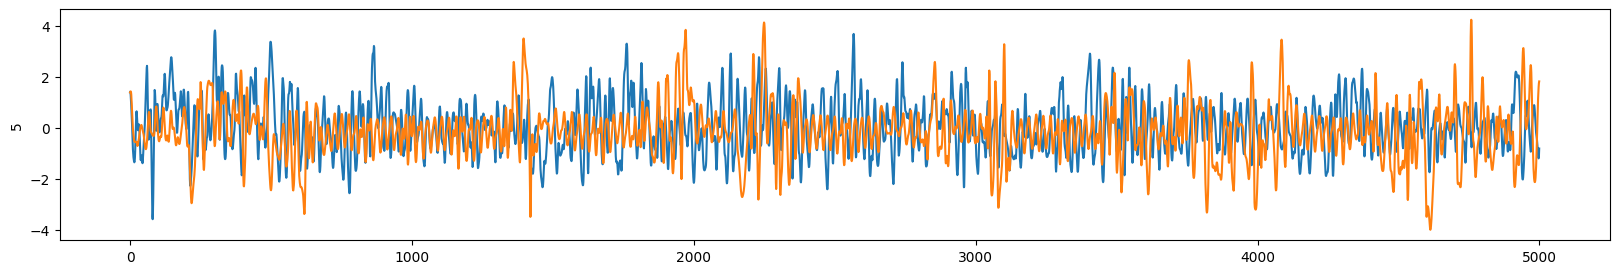

In [20]:
for i in range(5):
    plt.figure(figsize=[20,3])
    plt.plot(read_data_slice[i, :5*10**3])
    plt.plot(predictions[i, :5*10**3])
    plt.ylabel(i+1)
    plt.show()


In [21]:
import scipy.io

mat_data = scipy.io.loadmat('./data_eigenworm2/EigenWorms.mat')
PC = mat_data['EigenWorms'].T[:5]
# PC = mat_data['EigenWorms'][-5:]


In [22]:
x_mean = 0
original_scale = scaler.inverse_transform(read_data_slice.T).T
x_reconstruct = np.dot(original_scale.T, PC) + x_mean    # reconstruct data from the projections

In [23]:
def angle2pos(angles):
    """
    convert from angles of consecutive segments of unit length to positions of their endpoints.
    inputs:
    angles: 1-d array, angles of consecutive segments.
    outputs:
    pos: 2-d array, each row is (x,y) coordinates of an endpoint, centered at zeros.
    """
    angles = x_mean + angles
    dx = np.cos(angles)
    dy = np.sin(angles)
    xsum = np.cumsum(dx)
    ysum = np.cumsum(dy)
    D = 100
    pos = np.zeros((D+1, 2))
    pos[1:,0] = xsum
    pos[1:,1] = ysum
    mean = np.mean(pos, axis=0)
    pos = pos - mean
    return pos

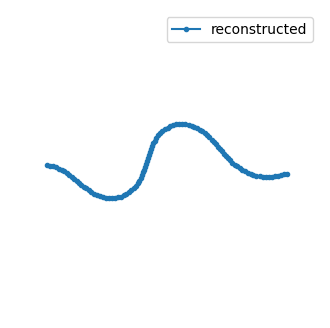

In [24]:
pos_reconstruct = angle2pos(x_reconstruct[10,:])    # reconstructed data

plt.figure(figsize=(4,4))
plt.plot(pos_reconstruct[:,0], pos_reconstruct[:,1], '.-', label='reconstructed')
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.legend()
plt.axis('off')
plt.show()

In [25]:
import matplotlib.animation as anim

x_project = read_data_slice.T

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**64
N = read_data_slice.shape[1]
start = 0
end = 1500
time = np.arange(0,N/4.,1./4.) #visualization time

fig, axes = plt.subplot_mosaic("ABD;CBD",figsize=(15,5))

#PC1
pA1, = axes["A"].plot(time,x_project[:,0],color="g")
pA2, = axes["A"].plot(time[start],x_project[start,0],color="k",marker="o")
axes["A"].set_xlim([start/4,end/4])
axes["A"].set_title("$a_1$")
axes["A"].xaxis.set_visible(False)

#PC2
pC1, = axes["C"].plot(time, x_project[:,1] ,color="b")
pC2, = axes["C"].plot(time[start],x_project[start,1],color="k",marker="o")
axes["C"].set_xlim([start/4,end/4])
axes["C"].set_title("$a_2$")
axes["C"].set_xlabel("time, sec")

#RECONSTRUCTION
# pos_original = angle2pos(data[start,:])
pos_reconstruct = angle2pos(x_reconstruct[start,:])
# pD2, = axes["D"].plot(pos_original[:,0],pos_original[:,1],marker=".",label="original",linewidth=6,markersize=15)
pD1, = axes["D"].plot(pos_reconstruct[:,0],pos_reconstruct[:,1],marker=".",label="reconstructed",linewidth=6,markersize=15)
# axes["D"].legend()
axes["D"].axis("equal")
axes["D"].axis("off")
axes["D"].set_xlim([-50,50])


#PROJECTION
mask = np.isfinite(x_project[:, 0]) & np.isfinite(x_project[:, 1])
pB1 = axes["B"].hist2d(x_project[mask, 0], x_project[mask, 1], bins=80)
# pB1 = axes["B"].hist2d(x_project[:,0],x_project[:,1],bins=80)
pB2, = axes["B"].plot(x_project[start,0],x_project[start,1],marker="o",color="red")
axes["B"].axis("equal")
axes["B"].set_xticks([],[])
axes["B"].set_yticks([],[])
axes["B"].set_xlabel("$a_1$")
axes["B"].set_ylabel("$a_2$")
for spine in axes["B"].spines.values():
    spine.set_visible(False)

def animate(t):
    pA2.set_data([time[t]],[x_project[t,0]])
    pC2.set_data([time[t]],[x_project[t,1]])


    # pos_original = angle2pos(data[t,:])
    pos_reconstruct = angle2pos(x_reconstruct[t,:])
    # pD2.set_data(pos_original[:,0],pos_original[:,1])
    pD1.set_data(pos_reconstruct[:,0],pos_reconstruct[:,1])


    pB2.set_data([x_project[t,0]],[x_project[t,1]])

    return (pA2,pC2,pD1,pB2)

# mov = anim.FuncAnimation(fig, animate, frames=range(start+1,end), interval=250) #interval in ms
step = 1  # show every 4th frame
mov = anim.FuncAnimation(fig, animate, frames=range(start+1, end, step), interval=250)
mov.save("data.gif", writer="pillow", fps=30)

plt.close()


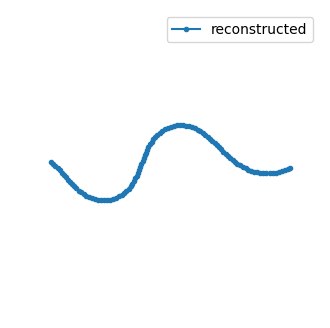

In [26]:
x_mean = 0
original_scale_pre = scaler.inverse_transform(predictions.T).T
x_reconstruct = np.dot(original_scale_pre.T, PC) + x_mean    # reconstruct data from the projections

pos_reconstruct = angle2pos(x_reconstruct[10,:])    # reconstructed data

plt.figure(figsize=(4,4))
plt.plot(pos_reconstruct[:,0], pos_reconstruct[:,1], '.-', label='reconstructed')
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.legend()
plt.axis('off')
plt.show()

In [ ]:
import matplotlib.animation as anim

x_project = predictions.T
N = x_project.shape[0]

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**64
start = 0
end = 1500
time = np.arange(0,N/4.,1./4.) #visualization time

fig, axes = plt.subplot_mosaic("ABD;CBD",figsize=(15,5))

#PC1
pA1, = axes["A"].plot(time,x_project[:,0],color="g")
pA2, = axes["A"].plot(time[start],x_project[start,0],color="k",marker="o")
axes["A"].set_xlim([start/4,end/4])
axes["A"].set_title("$a_1$")
axes["A"].xaxis.set_visible(False)

#PC2
pC1, = axes["C"].plot(time, x_project[:,1] ,color="b")
pC2, = axes["C"].plot(time[start],x_project[start,1],color="k",marker="o")
axes["C"].set_xlim([start/4,end/4])
axes["C"].set_title("$a_2$")
axes["C"].set_xlabel("time, sec")

#RECONSTRUCTION
# pos_original = angle2pos(data[start,:])
pos_reconstruct = angle2pos(x_reconstruct[start,:])
# pD2, = axes["D"].plot(pos_original[:,0],pos_original[:,1],marker=".",label="original",linewidth=6,markersize=15)
pD1, = axes["D"].plot(pos_reconstruct[:,0],pos_reconstruct[:,1],marker=".",label="reconstructed",linewidth=6,markersize=15)
# axes["D"].legend()
axes["D"].axis("equal")
axes["D"].axis("off")
axes["D"].set_xlim([-50,50])


#PROJECTION
pB1 = axes["B"].hist2d(x_project[:,0],x_project[:,1],bins=80)
pB2, = axes["B"].plot(x_project[start,0],x_project[start,1],marker="o",color="red")
axes["B"].axis("equal")
axes["B"].set_xticks([],[])
axes["B"].set_yticks([],[])
axes["B"].set_xlabel("$a_1$")
axes["B"].set_ylabel("$a_2$")
for spine in axes["B"].spines.values():
    spine.set_visible(False)

def animate(t):
    pA2.set_data([time[t]],[x_project[t,0]])
    pC2.set_data([time[t]],[x_project[t,1]])


    # pos_original = angle2pos(data[t,:])
    pos_reconstruct = angle2pos(x_reconstruct[t,:])
    # pD2.set_data(pos_original[:,0],pos_original[:,1])
    pD1.set_data(pos_reconstruct[:,0],pos_reconstruct[:,1])


    pB2.set_data([x_project[t,0]],[x_project[t,1]])

    return (pA2,pC2,pD1,pB2)

# mov = anim.FuncAnimation(fig, animate, frames=range(start+1,end), interval=250) #interval in ms
step = 1  # show every 4th frame
mov = anim.FuncAnimation(fig, animate, frames=range(start+1, end, step), interval=250)
mov.save("prediction.gif", writer="pillow", fps=30)

plt.close()
